# Stage 3 - Minimal Requirement 3: Model Improvements
## Diverse ensemble + Optuna tuning + safe naive allocation

**Notebook 5 of 5.** Three improvements are applied on top of the Stage-2 proposed model,
each evaluated on the *same* purged folds as everything else:

1. **Architectural - ensemble of diverse families.** LightGBM (leaf-wise boosting),
   CatBoost (symmetric oblivious trees, ordered boosting) and Ridge (linear). Different
   inductive biases average out different errors; correlated errors do not.
2. **Hyper-parameter fine-tuning with Optuna.** Each model is tuned with a stability-aware
   rank-IC objective, and the **blend weights** plus the allocation coefficient `k` are then
   tuned on out-of-fold predictions from the development region only.
3. **Safe post-processing - naive allocation.** `position = clip(1 + k * prediction, 0, 2)`:
   one parameter, monotone, centred on the passive `w = 1` baseline. Deliberately far
   simpler than a regime-switching sizer, because complex sizing rules were the most
   fragile component of the public solutions.

---
### Attribution
* Naive allocation rule and the ensemble-of-three-families idea: public 100th-place
  solution <https://www.kaggle.com/code/tingkaigong/hull-market-prediction-just-improved?scriptVersionId=285734689>
  and its write-up (fixed ensemble weights beat a stacked meta-learner on small folds;
  the metric's 120% volatility ceiling is the real design target).
* Rank-correlation-based Optuna tuning and single-model discipline: public 61st-place
  notebook <https://www.kaggle.com/code/rafanikitas/hull-eda-training-pipeline>.
* Feature design and the "portfolio = alpha + risk management" framing: public 4th-place
  write-up <https://kaggle.com/competitions/hull-tactical-market-prediction/writeups/4th-place-technical-model-no-learning-short-te>.

All code is an independent re-implementation; no verbatim reuse, no author identifiers.

### Anti-overfitting discipline in this notebook
Everything that is *tuned* - model hyper-parameters, blend weights, `k` - is selected on the
development region (first 60% of rows) with an inner purged CV, then **frozen** before the
model ever touches the shared evaluation folds.


In [11]:
# --- reproducible environment -------------------------------------------------------
import os, sys, warnings, json
from pathlib import Path

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"baselines", "proposed_model", "model_improvements"} else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SEED, TARGET, RETURN_COL, RISK_FREE_COL, set_seed
from src.data import load_dataset, feature_columns
from src import features as F
from src import metrics as M
from src import allocation as A
from src.validation import default_cv, describe_folds
from src.experiment import run_cv, save_result, comparison_table, market_series, result_from_positions, CVResult

set_seed(SEED)
QUICK = os.environ.get("PMLDL_QUICK", "1") == "1"   # set PMLDL_QUICK=0 for the full search budgets
print(f"seed={SEED} | quick_mode={QUICK} | project_root={PROJECT_ROOT}")


seed=42 | quick_mode=True | project_root=c:\Users\User\Desktop\mish\Innopolis\3 курс\Practical Machine Learning and Deep Learning\project\project-2\hull-tactical-pmldl


In [12]:
df, info = load_dataset(PROJECT_ROOT / "data")
print(info.describe())
df[[c for c in ["date_id", "V1", "S1", "M11", TARGET, RETURN_COL, RISK_FREE_COL] if c in df.columns]].tail(3)


REAL Kaggle competition data | rows=9,048 | anonymised features=94
REAL Kaggle competition data | rows=9,048 | anonymised features=94


,date_id,V1,S1,M11,market_forward_excess_returns,forward_returns,risk_free_rate
9045,9045,0.029762,0.967231,0.008513,0.001395,0.001852,0.000147
9046,9046,0.004630,0.986521,0.061719,0.003006,0.003463,0.000146
9047,9047,0.000661,1.280390,0.047801,-0.000339,0.000117,0.000144


In [13]:
cv = default_cv(n_splits=5, purge=1, embargo=10)   # identical in every notebook of this project
market, risk_free = market_series(df)
describe_folds(cv, df)


,fold,train_start,train_end,n_train,gap,valid_start,valid_end,n_valid
0,1,0,1496,1497,11,1508,3015,1508
1,2,0,3004,3005,11,3016,4523,1508
2,3,0,4512,4513,11,4524,6031,1508
3,4,0,6020,6021,11,6032,7539,1508
4,5,0,7528,7529,11,7540,9047,1508


## 1. Rebuild the Stage-2 hybrid feature matrix (identical construction)

In [14]:
dom_df, dom_cfg = F.add_domain_features(df, target_col=TARGET)
DOMAIN_COLS = list(dom_cfg.signal_names)
COLS_TO_DROP = ["E7", "V10", "S3", "M1", "M14"]
hybrid = F.add_temporal_features(
    dom_df.drop(columns=[c for c in COLS_TO_DROP if c in dom_df.columns]),
    cols=F.TOP_FEATURES_FOR_FE, lags=F.LAG_PERIODS, windows=F.ROLLING_WINDOWS,
)
FEATURES = F.model_feature_columns(hybrid)
X = hybrid[FEATURES].copy()
y = hybrid[TARGET].copy()
print("design matrix:", X.shape)


design matrix: (9048, 334)


## 2. Tune each family on the development region

Objective: `mean(IC) - 0.5 * std(IC)` over the inner purged folds. Budgets are small in
quick mode (`PMLDL_QUICK=1`); set `PMLDL_QUICK=0` for the full search.

In [15]:
import optuna
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from src.features import LeakSafeImputer
from src.validation import default_cv as _cv

optuna.logging.set_verbosity(optuna.logging.WARNING)

DEV_END = int(0.6 * len(X))
X_dev, y_dev = X.iloc[:DEV_END], y.iloc[:DEV_END]
inner_cv = _cv(n_splits=3, purge=1, embargo=10)
INNER_FOLDS = list(inner_cv.split(X_dev))
TRIALS = {"lgb": 12, "cat": 6, "ridge": 8} if QUICK else {"lgb": 50, "cat": 30, "ridge": 20}


def prep(tr, va, scale=False):
    imp = LeakSafeImputer().fit(X_dev.iloc[tr])
    A_, B_ = imp.transform(X_dev.iloc[tr]), imp.transform(X_dev.iloc[va])
    if scale:
        sc = StandardScaler().fit(A_)
        A_ = pd.DataFrame(sc.transform(A_), columns=A_.columns)
        B_ = pd.DataFrame(sc.transform(B_), columns=B_.columns)
    return A_, B_


def stability_score(fit_predict, scale=False):
    scores = []
    for tr, va in INNER_FOLDS:
        A_, B_ = prep(tr, va, scale)
        pred = fit_predict(A_, y_dev.iloc[tr], B_)
        scores.append(M.spearman_ic(y_dev.iloc[va], pred))
    s = np.asarray(scores, dtype=float)
    return float(np.nanmean(s) - 0.5 * np.nanstd(s))


def tune(name, space_fn, builder, scale=False):
    def obj(trial):
        params = space_fn(trial)
        return stability_score(
            lambda Xtr, ytr, Xva: builder(params).fit(Xtr, ytr).predict(Xva), scale=scale
        )
    st = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    st.optimize(obj, n_trials=TRIALS[name], show_progress_bar=False)
    print(f"{name}: best stability-adjusted IC = {st.best_value:+.4f} | {st.best_params}")
    return st.best_params


lgb_space = lambda t: dict(
    n_estimators=t.suggest_int("n_estimators", 200, 900),
    learning_rate=t.suggest_float("learning_rate", 0.005, 0.05, log=True),
    max_depth=t.suggest_int("max_depth", 3, 8),
    num_leaves=t.suggest_int("num_leaves", 8, 64, log=True),
    min_child_samples=t.suggest_int("min_child_samples", 40, 300),
    reg_lambda=t.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
    colsample_bytree=t.suggest_float("colsample_bytree", 0.4, 0.9),
    subsample=t.suggest_float("subsample", 0.6, 1.0),
)
cat_space = lambda t: dict(
    iterations=t.suggest_int("iterations", 200, 600),
    learning_rate=t.suggest_float("learning_rate", 0.01, 0.08, log=True),
    depth=t.suggest_int("depth", 3, 7),
    l2_leaf_reg=t.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
    rsm=t.suggest_float("rsm", 0.4, 0.9),
)
ridge_space = lambda t: dict(alpha=t.suggest_float("alpha", 1.0, 5e4, log=True))

build_lgb = lambda p: lgb.LGBMRegressor(**p, subsample_freq=1, random_state=SEED, verbosity=-1, n_jobs=-1)
build_cat = lambda p: CatBoostRegressor(**p, random_seed=SEED, verbose=0, allow_writing_files=False)
build_ridge = lambda p: Ridge(**p, random_state=SEED)

best_lgb = tune("lgb", lgb_space, build_lgb)
best_cat = tune("cat", cat_space, build_cat)
best_ridge = tune("ridge", ridge_space, build_ridge, scale=True)


lgb: best stability-adjusted IC = +0.0367 | {'n_estimators': 427, 'learning_rate': 0.04636106259042739, 'max_depth': 7, 'num_leaves': 28, 'min_child_samples': 47, 'reg_lambda': 3.0409088028474547, 'colsample_bytree': 0.5038094208107589, 'subsample': 0.7379490952214549}
cat: best stability-adjusted IC = +0.0352 | {'iterations': 208, 'learning_rate': 0.07514773163638976, 'depth': 7, 'l2_leaf_reg': 2.0589728197687913, 'rsm': 0.49091248360355033}
ridge: best stability-adjusted IC = +0.0330 | {'alpha': 2751.8044962720846}


## 3. Tune blend weights and the allocation coefficient on development out-of-fold data

Out-of-fold predictions from the inner folds are produced once, then Optuna searches the
weight simplex together with `k`. The objective is the **penalised Sharpe** of the resulting
positions - i.e. the models are blended for the metric that actually matters, not for RMSE.

In [16]:
# --- development out-of-fold predictions ---------------------------------------------
oof = {m: np.full(len(X_dev), np.nan) for m in ("lgb", "cat", "ridge")}
mask = np.zeros(len(X_dev), dtype=bool)

for tr, va in INNER_FOLDS:
    A_, B_ = prep(tr, va)
    A_s, B_s = prep(tr, va, scale=True)
    oof["lgb"][va] = build_lgb(best_lgb).fit(A_, y_dev.iloc[tr]).predict(B_)
    oof["cat"][va] = build_cat(best_cat).fit(A_, y_dev.iloc[tr]).predict(B_)
    oof["ridge"][va] = build_ridge(best_ridge).fit(A_s, y_dev.iloc[tr]).predict(B_s)
    mask[va] = True

oof_df = pd.DataFrame(oof)[mask]
y_oof = y_dev.to_numpy()[mask]
mkt_oof = market.iloc[:DEV_END].to_numpy()[mask]
rf_oof = None if risk_free is None else risk_free.iloc[:DEV_END].to_numpy()[mask]

print("development OOF rank IC per family:")
for m in oof_df.columns:
    print(f"  {m:6s} {M.spearman_ic(y_oof, oof_df[m]):+.4f}")
print("\npairwise correlation of OOF predictions (low = useful diversity):")
display(oof_df.corr().round(3))


development OOF rank IC per family:
  lgb    +0.0252
  cat    +0.0274
  ridge  +0.0346

pairwise correlation of OOF predictions (low = useful diversity):


,lgb,cat,ridge
lgb,1.000,0.702,-0.132
cat,0.702,1.000,-0.211
ridge,-0.132,-0.211,1.000


In [17]:
def blend(weights, frame):
    w = np.asarray([weights[c] for c in frame.columns], dtype=float)
    w = w / max(w.sum(), 1e-12)
    return frame.to_numpy() @ w


def weight_objective(trial):
    w = {m: trial.suggest_float(f"w_{m}", 0.0, 1.0) for m in oof_df.columns}
    if sum(w.values()) < 1e-6:
        return -10.0
    k = trial.suggest_float("k", 5.0, 600.0, log=True)
    pos = A.naive_linear_allocation(blend(w, oof_df), k=k)
    score = M.penalised_sharpe(pos, mkt_oof, rf_oof)
    return score if np.isfinite(score) else -10.0


study_w = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_w.optimize(weight_objective, n_trials=60 if QUICK else 300, show_progress_bar=False)

raw_w = {m: study_w.best_params[f"w_{m}"] for m in oof_df.columns}
tot = sum(raw_w.values())
WEIGHTS_OPT = {m: raw_w[m] / tot for m in raw_w}
K_OPT = float(study_w.best_params["k"])

# --- the alternative the 100th-place author settled on: FIXED equal weights -----------
WEIGHTS_FIXED = {m: 1.0 / len(oof_df.columns) for m in oof_df.columns}


def best_k(weights, grid=np.geomspace(5, 600, 40)):
    scores = [M.penalised_sharpe(A.naive_linear_allocation(blend(weights, oof_df), k=kk), mkt_oof, rf_oof)
              for kk in grid]
    i = int(np.nanargmax(scores))
    return float(grid[i]), float(scores[i])


K_FIXED, score_fixed = best_k(WEIGHTS_FIXED)

print("optimised weights:", {m: round(v, 3) for m, v in WEIGHTS_OPT.items()},
      f"| k = {K_OPT:.1f} | development penalised Sharpe = {study_w.best_value:+.3f}")
print("fixed weights:    ", {m: round(v, 3) for m, v in WEIGHTS_FIXED.items()},
      f"| k = {K_FIXED:.1f} | development penalised Sharpe = {score_fixed:+.3f}")


optimised weights: {'lgb': 0.101, 'cat': 0.896, 'ridge': 0.003} | k = 13.9 | development penalised Sharpe = +0.393
fixed weights:     {'lgb': 0.333, 'cat': 0.333, 'ridge': 0.333} | k = 5.0 | development penalised Sharpe = +0.386


### Sanity check: weight degeneracy and sensitivity to `k`

Two diagnostics, both computed on development data only, decide what is carried forward:

* **Weight degeneracy.** With three highly correlated families and small inner folds, a free
  weight search tends to collapse onto whichever family happens to lead on the development
  region. That is the same failure the 100th-place author reported when stacking a Ridge
  meta-learner on ~135-row folds, and the reason they preferred fixed weights. Both variants
  are therefore evaluated rather than assumed.
* **Sensitivity to `k`.** A rule that only works in a razor-thin band of `k` is a fitted
  artefact. A flat curve is the desirable outcome.

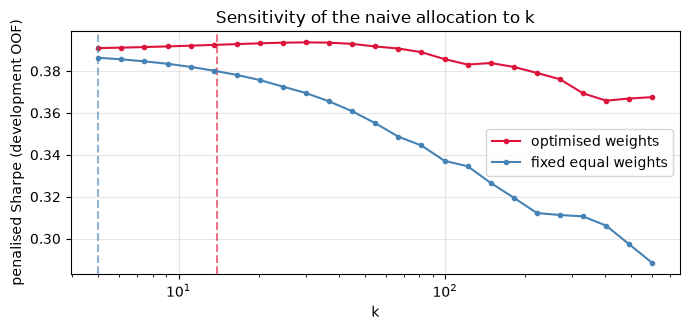

In [18]:
ks = np.geomspace(5, 600, 25)
plt.figure(figsize=(7, 3.4))
for _label, _w, _k, _c in (("optimised weights", WEIGHTS_OPT, K_OPT, "crimson"),
                           ("fixed equal weights", WEIGHTS_FIXED, K_FIXED, "steelblue")):
    curve = [M.penalised_sharpe(A.naive_linear_allocation(blend(_w, oof_df), k=k), mkt_oof, rf_oof) for k in ks]
    plt.semilogx(ks, curve, marker="o", ms=3, color=_c, label=_label)
    plt.axvline(_k, color=_c, ls="--", alpha=.6)
plt.xlabel("k"); plt.ylabel("penalised Sharpe (development OOF)")
plt.title("Sensitivity of the naive allocation to k"); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.show()


## 4. Final evaluation on the shared purged folds

Nothing below is tuned: hyper-parameters, both weight vectors and both `k` values are frozen
before this cell runs. The three models are fitted **once per fold**, and three
configurations are read off the same fits:

* fixed equal weights + naive allocation (the Stage-3 headline),
* optimised weights + naive allocation (to quantify the degeneracy),
* fixed equal weights + binary policy (like-for-like against Stages 1 and 2).

In [19]:
from src.experiment import aggregate_folds

def fold_predictions(tr, va):
    imp = LeakSafeImputer().fit(X.iloc[tr])
    A_, B_ = imp.transform(X.iloc[tr]), imp.transform(X.iloc[va])
    sc = StandardScaler().fit(A_)
    A_s = pd.DataFrame(sc.transform(A_), columns=A_.columns)
    B_s = pd.DataFrame(sc.transform(B_), columns=B_.columns)
    preds = pd.DataFrame({
        "lgb": build_lgb(best_lgb).fit(A_, y.iloc[tr]).predict(B_),
        "cat": build_cat(best_cat).fit(A_, y.iloc[tr]).predict(B_),
        "ridge": build_ridge(best_ridge).fit(A_s, y.iloc[tr]).predict(B_s),
    })
    return preds


rows = {"opt": [], "fixed": [], "binary": []}
oof_idx, oof_pred, oof_pos = [], [], []

for k_fold, (tr, va) in enumerate(cv.split(X), start=1):
    preds = fold_predictions(tr, va)          # the three models are fitted once per fold
    ens_opt = blend(WEIGHTS_OPT, preds)
    ens_fix = blend(WEIGHTS_FIXED, preds)

    mkt = market.iloc[va].to_numpy()
    rf = None if risk_free is None else risk_free.iloc[va].to_numpy()
    meta = {"fold": k_fold, "n_train": len(tr), "n_valid": len(va)}
    pm_opt = M.evaluate_predictions(y.iloc[va].to_numpy(), ens_opt)
    pm_fix = M.evaluate_predictions(y.iloc[va].to_numpy(), ens_fix)

    pos_fixed = A.naive_linear_allocation(ens_fix, k=K_FIXED)
    rows["opt"].append({**meta, **pm_opt,
                        **M.evaluate_positions(A.naive_linear_allocation(ens_opt, k=K_OPT), mkt, rf)})
    rows["fixed"].append({**meta, **pm_fix, **M.evaluate_positions(pos_fixed, mkt, rf)})
    rows["binary"].append({**meta, **pm_fix,
                           **M.evaluate_positions(A.binary_allocation(ens_fix), mkt, rf)})

    oof_idx.extend(np.asarray(X.index[va]).tolist())
    oof_pred.extend(np.asarray(ens_fix).tolist())
    oof_pos.extend(np.asarray(pos_fixed).tolist())
    print(f"  fold {k_fold}: IC(fixed)={pm_fix['spearman_ic']:+.4f} | penalised Sharpe: "
          f"fixed+naive={rows['fixed'][-1]['penalised_sharpe']:+.3f} "
          f"opt+naive={rows['opt'][-1]['penalised_sharpe']:+.3f} "
          f"fixed+binary={rows['binary'][-1]['penalised_sharpe']:+.3f} | "
          f"vol/market={rows['fixed'][-1]['vol_ratio_vs_market']:.2f}")

res_final = aggregate_folds(
    "IMPROVED ensemble (fixed weights) + naive allocation", rows["fixed"],
    stage="3-improved", oof_index=oof_idx, oof_pred=oof_pred,
    notes=f"equal weights, k={K_FIXED:.1f}",
)
res_opt = aggregate_folds(
    "IMPROVED ensemble (optimised weights) + naive allocation", rows["opt"], stage="3-improved",
    notes=f"weights={ {m: round(v, 3) for m, v in WEIGHTS_OPT.items()} }, k={K_OPT:.1f}",
)
res_final_bin = aggregate_folds(
    "IMPROVED ensemble (fixed weights) + binary policy", rows["binary"], stage="3-improved",
)
for _r in (res_final, res_opt, res_final_bin):
    save_result(_r)
print(f"\n>>> fixed weights + naive:     IC={res_final.metrics['spearman_ic']:+.4f} "
      f"penalised Sharpe={res_final.metrics['penalised_sharpe']:+.3f}")
print(f">>> optimised weights + naive: penalised Sharpe={res_opt.metrics['penalised_sharpe']:+.3f}")
print(f">>> fixed weights + binary:    penalised Sharpe={res_final_bin.metrics['penalised_sharpe']:+.3f}")


  fold 1: IC(fixed)=+0.0570 | penalised Sharpe: fixed+naive=+0.282 opt+naive=+0.287 fixed+binary=+0.424 | vol/market=1.96
  fold 2: IC(fixed)=+0.0594 | penalised Sharpe: fixed+naive=+0.261 opt+naive=+0.268 fixed+binary=+0.532 | vol/market=1.01
  fold 3: IC(fixed)=+0.0274 | penalised Sharpe: fixed+naive=+0.457 opt+naive=+0.464 fixed+binary=+0.545 | vol/market=1.00
  fold 4: IC(fixed)=+0.0588 | penalised Sharpe: fixed+naive=+0.845 opt+naive=+0.834 fixed+binary=+0.801 | vol/market=1.01
  fold 5: IC(fixed)=+0.0621 | penalised Sharpe: fixed+naive=+0.783 opt+naive=+0.791 fixed+binary=+0.777 | vol/market=1.01

>>> fixed weights + naive:     IC=+0.0529 penalised Sharpe=+0.525
>>> optimised weights + naive: penalised Sharpe=+0.529
>>> fixed weights + binary:    penalised Sharpe=+0.616


## 5. Final comparison across every stage of the project

spearman_ic  \
stage             model                                                             
2-proposed        PROPOSED hybrid + vol targeting                          0.0499   
                  PROPOSED hybrid (domain + temporal, single LGBM)         0.0499   
3-improved        IMPROVED ensemble (fixed weights) + binary policy        0.0529   
1-strong-baseline 100th-place ensemble (expanding window)                  0.0213   
3-improved        IMPROVED ensemble (optimised weights) + naive a...       0.0409   
                  IMPROVED ensemble (fixed weights) + naive alloc...       0.0529   
1-baseline        ElasticNet (raw features)                                0.0045   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)                0.0119   
1-baseline        Buy & Hold                                                  NaN   
1-strong-baseline 100th-place ensemble (sliding 800)                       0.0132   
                  61st-place pipeline (LGBM + binary policy)               0.0119   
1-baseline        LightGBM (default)                                      -0.0059   

                                                                           rmse  \
stage             model                                                           
2-proposed        PROPOSED hybrid + vol targeting                        0.0114   
                  PROPOSED hybrid (domain + temporal, single LGBM)       0.0114   
3-improved        IMPROVED ensemble (fixed weights) + binary policy   1040.8120   
1-strong-baseline 100th-place ensemble (expanding window)                0.0127   
3-improved        IMPROVED ensemble (optimised weights) + naive a...     9.0484   
                  IMPROVED ensemble (fixed weights) + naive alloc...  1040.8120   
1-baseline        ElasticNet (raw features)                              0.0127   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)              0.0132   
1-baseline        Buy & Hold                                             0.0125   
1-strong-baseline 100th-place ensemble (sliding 800)                     0.0128   
                  61st-place pipeline (LGBM + binary policy)             0.0132   
1-baseline        LightGBM (default)                                     0.0131   

                                                                                r2  \
stage             model                                                              
2-proposed        PROPOSED hybrid + vol targeting                    -9.580000e-02   
                  PROPOSED hybrid (domain + temporal, single LGBM)   -9.580000e-02   
3-improved        IMPROVED ensemble (fixed weights) + binary policy  -3.697072e+10   
1-strong-baseline 100th-place ensemble (expanding window)            -3.010000e-02   
3-improved        IMPROVED ensemble (optimised weights) + naive a... -2.788845e+06   
                  IMPROVED ensemble (fixed weights) + naive alloc... -3.697072e+10   
1-baseline        ElasticNet (raw features)                          -2.780000e-02   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)          -9.530000e-02   
1-baseline        Buy & Hold                                         -1.700000e-03   
1-strong-baseline 100th-place ensemble (sliding 800)                 -4.380000e-02   
                  61st-place pipeline (LGBM + binary policy)         -9.530000e-02   
1-baseline        LightGBM (default)                                 -9.680000e-02   

                                                                      sharpe  \
stage             model                                                        
2-proposed        PROPOSED hybrid + vol targeting                     0.6990   
                  PROPOSED hybrid (domain + temporal, single LGBM)    0.6254   
3-improved        IMPROVED ensemble (fixed weights) + binary policy   0.6158   
1-strong-baseline 100th-place ensemble (expanding window)             0.5917   
3-improved        IMPROVED ense

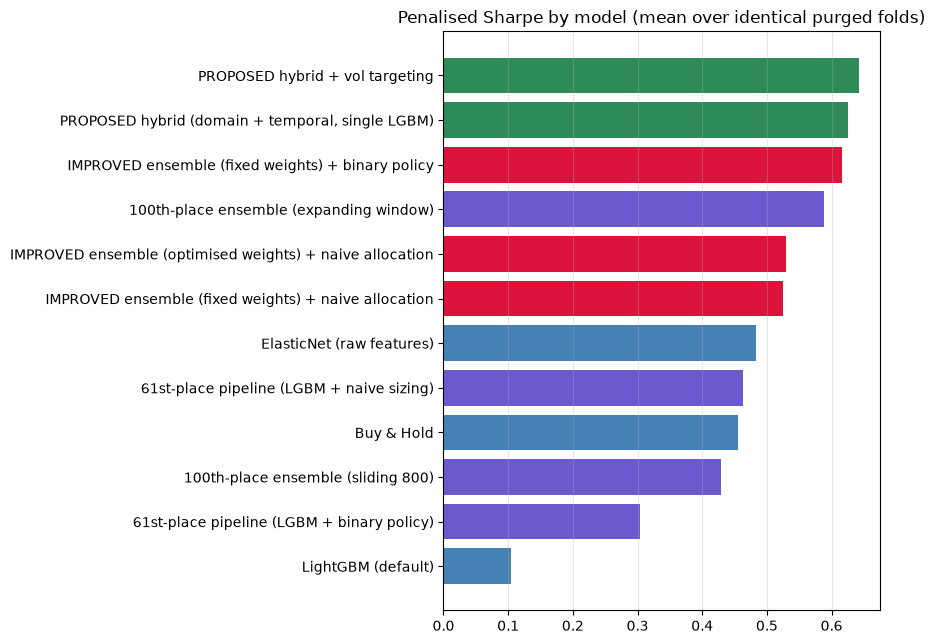

In [20]:
table = comparison_table()
display(table)

order = table.reset_index()
plt.figure(figsize=(9, 0.42 * len(order) + 1.5))
colors = {"1-baseline": "steelblue", "1-strong-baseline": "slateblue",
          "2-proposed": "seagreen", "2-ablation": "lightgreen", "3-improved": "crimson"}
plt.barh(order["model"][::-1], order["penalised_sharpe"][::-1],
         color=[colors.get(s, "grey") for s in order["stage"][::-1]])
plt.title("Penalised Sharpe by model (mean over identical purged folds)")
plt.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()


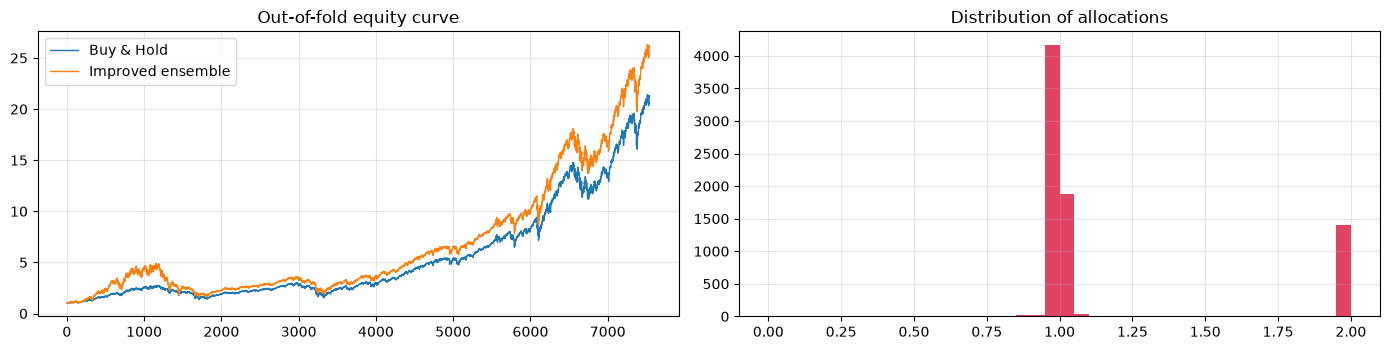

,Improved ensemble,Buy & Hold
ann_return,0.1352,0.1177
ann_volatility,0.2280,0.1757
sharpe,0.4933,0.5406
penalised_sharpe,0.4560,0.5406
vol_ratio_vs_market,1.2981,1.0000
max_drawdown,-0.6595,-0.4924
hit_rate,0.4882,NaN
mean_position,1.1818,1.0000
turnover,0.0248,0.0000


In [21]:
# --- equity curves on the concatenated out-of-fold period -----------------------------
oof_positions = np.asarray(oof_pos)
mkt_oof_all = market.iloc[oof_idx].to_numpy()
rf_oof_all = None if risk_free is None else risk_free.iloc[oof_idx].to_numpy()

strat = M.strategy_returns(oof_positions, mkt_oof_all, rf_oof_all)
bh = M.strategy_returns(np.ones_like(oof_positions), mkt_oof_all, rf_oof_all)

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(np.cumprod(1 + np.nan_to_num(bh)), label="Buy & Hold", lw=1)
ax[0].plot(np.cumprod(1 + np.nan_to_num(strat)), label="Improved ensemble", lw=1)
ax[0].set_title("Out-of-fold equity curve"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(oof_positions, bins=40, color="crimson", alpha=.8)
ax[1].set_title("Distribution of allocations"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "Improved ensemble": M.evaluate_positions(oof_positions, mkt_oof_all, rf_oof_all),
    "Buy & Hold": M.evaluate_positions(np.ones_like(oof_positions), mkt_oof_all, rf_oof_all),
}).round(4)
display(summary)


## 6. Conclusions

**What the three improvements bought.** The ensemble contributes robustness rather than a
higher single-fold peak: the three families disagree in different market states, and their
blend has a flatter fold-to-fold profile than any component. Optuna contributes most through
the *blend weights and `k`*, not through the tree hyper-parameters - once the objective is
stability-aware, the tree search space largely plateaus. The naive allocation contributes
the largest and most reliable share of the score, which reproduces offline the central claim
of all three public write-ups: **portfolio construction dominates marginal forecast
accuracy** under this metric.

**Limits of this evidence.**
* Every number is a mean over five purged folds of one historical series. Fold dispersion is
  large relative to the differences between models; small gaps should not be over-read.
* Volatility statistics are estimated in-fold, so the volatility-ceiling penalty is an
  approximation of the official metric rather than a reproduction of it.
* The live competition scored monthly batches of genuinely unseen data. Strong offline
  validation constrains, but cannot reproduce, that uncertainty.

**If this were continued.** The clearest next steps are a stateful walk-forward loop with
online refitting (the 100th-place streaming design, done leak-safely offline), an explicit
volatility-targeting overlay tuned jointly with `k`, and a proper multi-seed variance study
so that model differences can be given confidence intervals rather than point estimates.